# Data Workflow

### ***Nina Haide***


This project explores the AI job market in the DACH area (Germany, Austria and Switzerland) through live data collected from the Adzuna jobs API. The dataset covers a broad spectrum of AI roles - from engineering and data science to consulting, product management and system integration - reflecting the diverse career paths available to candidates with both technical and business backgrounds. The goal is to identify patterns in role demand, seniority distribution and salary transparency across different AI job categories.

442 job postings scraped live from the Adzuna API in May 2025, covering AI-related roles across Germany (361), Austria (37) and Switzerland (44). The dataset spans five role categories - AI Engineering, Data Analytics, AI Product/Project Management, AI Integration and AI Consulting - and includes job title, company, location, country, contract type, salary where disclosed, posting date and a short description excerpt. Salary data is intentionally sparse, with only 21 of 442 postings disclosing compensation figures, reflecting a well-documented pattern of salary opacity in job markets.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All good ✅")

All good ✅


## Data Set

In [12]:
df = pd.read_csv("adzuna_ai_jobs_dach.csv")
df.head()

,id,title,company,location,country,category,contract_type,contract_time,salary_min,salary_max,date_posted,description,role_category,search_query,url
0,de_5708353171,Senior Engineer Machine Learning / AI (w/m/d),HUK-COBURG Versicherungsgruppe,"Coburg, Coburg (Kreis)",Germany,IT-Stellen,NaN,NaN,NaN,NaN,2026-04-23,"Hallo, lass uns WIR sagen! Wir - die HUK-COBUR...",AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/land/ad/5708353171?se=WG...
1,de_5680334179,Digital Process Engineer – AI & Automation (KI...,GPE MedTech Systeme GmbH,"Dassow, Nordwestmecklenburg (Kreis)",Germany,Beraterstellen,NaN,NaN,NaN,NaN,2026-03-27,Digital Process Engineer – AI & Automation (KI...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5680334179?utm_m...
2,de_5418313407,Senior AI / Machine Learning Engineer – Enterp...,Nortal,Deutschland,Germany,IT-Stellen,permanent,full_time,NaN,NaN,2025-09-27,Wir bei Nortal unterstützen den öffentlichen S...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5418313407?utm_m...
3,de_5698582069,AI & Machine Learning Engineer – Sensor Fusion...,Collective.work,"Altstadt-Lehel, München",Germany,Sonstige/Allgemeine Stellen,permanent,full_time,65000.0,105000.0,2026-04-14,Job description Salary: 65-105k€ (Annuel) AI &...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5698582069?utm_m...
4,de_5104382632,Staff Machine Learning Engineer (AI Platform),Smartly,"Berlin, Deutschland",Germany,IT-Stellen,NaN,full_time,NaN,NaN,2025-03-21,We are looking for a Staff Machine Learning En...,AI_Engineering,AI Engineer Machine Learning,https://www.adzuna.de/details/5104382632?utm_m...


In [13]:
df.count()


id               442
title            442
company          441
location         442
country          442
category         442
contract_type     65
contract_time    191
salary_min        21
salary_max        21
date_posted      442
description      442
role_category    442
search_query     442
url              442
dtype: int64

## Data Cleaning

In [40]:
import re

def clean_job_titles(df):
    """Strip gender suffixes, em-dashes, ref numbers and extra whitespace from job titles."""
    df = df.copy()
    
    title = df["title"].astype(str)
    
    # Remove gender notation variants: (w/m/d), (m/w/d), (f/m/d), (KI/m/w/d), etc.
    title = title.str.replace(r"\([fmwdkiKI/]+\)", "", regex=True)
    
    # Remove em-dashes and surrounding whitespace
    title = title.str.replace(r"\s*[–—-]\s*", " ", regex=True)
    
    # Remove trailing reference numbers / job IDs (e.g. "Ref. 12345", "#42", "(m42)")
    title = title.str.replace(r"\s*(Ref\.?\s*\d+|#\d+|\(\w*\d+\w*\))", "", regex=True)
    
    # Collapse multiple spaces and strip
    title = title.str.replace(r"\s{2,}", " ", regex=True).str.strip()
    
    df["title_clean"] = title
    def _seniority(title: str) -> str:
        t = title.lower()
        if any(k in t for k in ['lead', 'principal', 'staff']):
            return 'Lead'
        if any(k in t for k in ['head of', 'director', 'vp ', 'vice president', 'manager']):
            return 'Manager'
        if 'senior' in t or ' sr.' in t:
            return 'Senior'
        if any(k in t for k in ['junior', ' jr.', 'entry', 'trainee', 'werkstudent']):
            return 'Junior'
        return 'Mid'

    df['seniority'] = df['title_clean'].apply(_seniority)
    return df

df = clean_job_titles(df)
df[["title", "title_clean"]].head(10)

,title,title_clean
0,Senior Engineer Machine Learning / AI (w/m/d),Senior Engineer Machine Learning / AI
1,Digital Process Engineer – AI & Automation (KI...,Digital Process Engineer AI & Automation (KI E...
2,Senior AI / Machine Learning Engineer – Enterp...,Senior AI / Machine Learning Engineer Enterpri...
3,AI & Machine Learning Engineer – Sensor Fusion...,AI & Machine Learning Engineer Sensor Fusion &...
4,Staff Machine Learning Engineer (AI Platform),Staff Machine Learning Engineer (AI Platform)
5,Senior Machine Learning Engineer (AI Platform),Senior Machine Learning Engineer (AI Platform)
6,Senior Engineer Machine Learning / AI (w/m/d),Senior Engineer Machine Learning / AI
7,Senior Engineer Machine Learning / AI (w/m/d),Senior Engineer Machine Learning / AI
8,Senior Machine Learning/AI Engineer (m/w/d),Senior Machine Learning/AI Engineer
9,Machine Learning Engineer - AI Insights (gn) f...,Machine Learning Engineer AI Insights (gn) ful...


In [41]:
HOURLY_THRESHOLD = 500  # values below this are almost certainly hourly rates, not annual

def clean_salary_data(df):
    """Flag implausible salaries, add availability flag, compute midpoint."""
    df = df.copy()
    
    # Flag rows where salary looks like an hourly rate (e.g. 80.0)
    df["salary_likely_hourly"] = (
        df["salary_min"].notna() & (df["salary_min"] < HOURLY_THRESHOLD)
    ) | (
        df["salary_max"].notna() & (df["salary_max"] < HOURLY_THRESHOLD)
    )
    
    # Null out implausible values so they don't skew analysis
    df.loc[df["salary_likely_hourly"], ["salary_min", "salary_max"]] = None
    
    # Boolean flag: does this row have any usable salary data?
    df["salary_available"] = df["salary_min"].notna() | df["salary_max"].notna()
    
    # Midpoint: average of min+max where both exist; fall back to whichever is present
    df["salary_midpoint"] = df[["salary_min", "salary_max"]].mean(axis=1)
    
    return df

df = clean_salary_data(df)

print(f"Salary available:    {df['salary_available'].sum()} / {len(df)} rows")
print(f"Likely hourly rate:  {df['salary_likely_hourly'].sum()} rows nulled out")
print(f"Midpoint range:      €{df['salary_midpoint'].min():,.0f} – €{df['salary_midpoint'].max():,.0f}")
df[["title_clean", "salary_min", "salary_max", "salary_midpoint", "salary_available"]].dropna(subset=["salary_midpoint"]).head()

Salary available:    18 / 442 rows
Likely hourly rate:  0 rows nulled out
Midpoint range:      €10,818 – €416,000


,title_clean,salary_min,salary_max,salary_midpoint,salary_available
3,AI & Machine Learning Engineer Sensor Fusion &...,65000.0,105000.0,85000.0,True
11,Full Stack Engineer,75000.0,100000.0,87500.0,True
19,Staff Backend Developer (Python),80000.0,110000.0,95000.0,True
24,Sr. Product Manager,115000.0,130000.0,122500.0,True
25,Staff Product Manager,115000.0,130000.0,122500.0,True


## EDA Functions

In [47]:
def summarise_dataset(df: pd.DataFrame) -> None:
    """
    Prints a structured overview of the dataset's shape, column
    completeness, and key categorical distributions.

    Covers three areas relevant to this dataset:
    (1) Overall shape and missing value rates — highlights the
        structural sparsity in salary, contract_type, and
        contract_time that affects downstream analysis.
    (2) Role category and country distribution — shows how
        postings are split across the five AI role segments
        and three DACH countries.
    (3) Top hiring locations — identifies the cities and regions
        with the highest concentration of AI job postings.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned job postings DataFrame.

    Returns
    -------
    None — prints output directly.
    """
    print("=" * 55)
    print(f"  DATASET OVERVIEW")
    print("=" * 55)
    print(f"  Rows:     {len(df)}")
    print(f"  Columns:  {len(df.columns)}")
    print(f"  Countries: {', '.join(sorted(df['country'].unique()))}")
    print(f"  Date range: {df['date_posted'].min()}  →  {df['date_posted'].max()}")

    print("\n--- Missing Values ---")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_df = pd.DataFrame({"missing": missing, "%": missing_pct})
    print(missing_df[missing_df["missing"] > 0].to_string())

    print("\n--- Role Category Distribution ---")
    rc = df["role_category"].value_counts()
    rc_pct = (rc / len(df) * 100).round(1)
    print(pd.DataFrame({"count": rc, "%": rc_pct}).to_string())

    print("\n--- Country Distribution ---")
    cc = df["country"].value_counts()
    cc_pct = (cc / len(df) * 100).round(1)
    print(pd.DataFrame({"count": cc, "%": cc_pct}).to_string())

    print("\n--- Top 10 Locations ---")
    print(df["location"].value_counts().head(10).to_string())

    print("\n--- Contract Time (where available) ---")
    print(df["contract_time"].value_counts().to_string())

    print("\n--- Salary Availability ---")
    avail = df["salary_min"].notna().sum()
    print(f"  Rows with salary data: {avail} / {len(df)} ({avail/len(df)*100:.1f}%)")

In [48]:
summarise_dataset(df)

  DATASET OVERVIEW
  Rows:     442
  Columns:  20
  Countries: Austria, Germany, Switzerland
  Date range: 2023-11-14  →  2026-05-05

--- Missing Values ---
                 missing     %
company                1   0.2
contract_type        377  85.3
contract_time        251  56.8
salary_min           424  95.9
salary_max           424  95.9
salary_midpoint      424  95.9

--- Role Category Distribution ---
                count     %
role_category              
AI_Engineering    131  29.6
Data_Analytics    108  24.4
AI_PM              98  22.2
AI_Integration     82  18.6
AI_Consulting      23   5.2

--- Country Distribution ---
             count     %
country                 
Germany        361  81.7
Switzerland     44  10.0
Austria         37   8.4

--- Top 10 Locations ---
location
Deutschland                        65
Berlin, Deutschland                36
München, München (Kreis)           31
Schweiz                            23
Wien, Österreich                   14
Walldorf, Rhei

In [49]:
def analyse_by_group(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns grouped views of job postings by role category and
    country, including posting counts, seniority breakdown, and
    salary availability per group.

    This function is designed to reveal structural differences
    between AI role segments — for example, whether consulting
    roles skew more senior than engineering roles, or whether
    salary disclosure rates differ by country.  These grouped
    views form the basis for the visualisations in Task 7.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned DataFrame with 'role_category', 'country',
        'seniority', and 'salary_available' columns.

    Returns
    -------
    pd.DataFrame
        Summary table grouped by role_category and country.
    """
    print("=" * 55)
    print("  GROUPED ANALYSIS")
    print("=" * 55)

    # 1 — Postings by role category × country
    print("\n--- Postings: Role Category × Country ---")
    cross = pd.crosstab(df["role_category"], df["country"])
    cross["TOTAL"] = cross.sum(axis=1)
    print(cross.to_string())

   # 2 — Seniority breakdown by role category (requires clean_job_titles to have run)
    print("\n--- Seniority × Role Category ---")
    if "seniority" in df.columns:
        seniority_cross = pd.crosstab(
        df["seniority"], df["role_category"], margins=True
        )
        print(seniority_cross.to_string())
    else:
        print("  ⚠  'seniority' column not found — run clean_job_titles(df) first.")

    # 3 — Salary availability by country
    print("\n--- Salary Availability by Country ---")
    sal_country = df.groupby("country")["salary_available"].agg(
        postings="count",
        with_salary="sum"
    )
    sal_country["salary_%"] = (
        sal_country["with_salary"] / sal_country["postings"] * 100
    ).round(1)
    print(sal_country.to_string())

    # 4 — Salary availability by role category
    print("\n--- Salary Availability by Role Category ---")
    sal_role = df.groupby("role_category")["salary_available"].agg(
        postings="count",
        with_salary="sum"
    )
    sal_role["salary_%"] = (
        sal_role["with_salary"] / sal_role["postings"] * 100
    ).round(1)
    print(sal_role.to_string())

    # 5 — Full grouped summary table
    summary = df.groupby(["role_category", "country"]).agg(
        postings=("id", "count"),
        salary_disclosed=("salary_available", "sum"),
        avg_salary_midpoint=("salary_midpoint", "mean")
    ).round(0)
    summary["salary_%"] = (
        summary["salary_disclosed"] / summary["postings"] * 100
    ).round(1)

    print("\n--- Full Summary Table ---")
    print(summary.to_string())

    return summary

In [50]:
group_summary = analyse_by_group(df)

  GROUPED ANALYSIS

--- Postings: Role Category × Country ---
country         Austria  Germany  Switzerland  TOTAL
role_category                                       
AI_Consulting         2       15            6     23
AI_Engineering        4      110           17    131
AI_Integration        8       73            1     82
AI_PM                 9       75           14     98
Data_Analytics       14       88            6    108

--- Seniority × Role Category ---
role_category  AI_Consulting  AI_Engineering  AI_Integration  AI_PM  Data_Analytics  All
seniority                                                                               
Junior                     1               7              17      0               2   27
Lead                       1              24               5     19               8   57
Manager                   18               9              10     56              14  107
Mid                        1              74              45      8              72  20

In [51]:
def check_correlations(df: pd.DataFrame) -> None:
    """
    Examines relationships between key variables in the dataset
    using a correlation matrix on encoded categorical fields and
    a focused salary analysis where data is available.

    Because most numeric columns (salary_min, salary_max) are
    sparse, this function encodes the categorical variables
    role_category, country, seniority, and contract_time as
    ordinal integers before computing correlations.  Results
    should be interpreted cautiously given the small salary
    sample (n=21) and the encoding assumptions made.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned DataFrame including encoded and salary columns.

    Returns
    -------
    None — prints output directly.
    """
    print("=" * 55)
    print("  CORRELATION ANALYSIS")
    print("=" * 55)

# Encode categoricals for correlation
    enc = df.copy()
    enc["role_enc"]    = enc["role_category"].astype("category").cat.codes
    enc["country_enc"] = enc["country"].astype("category").cat.codes
    enc["time_enc"]    = enc["contract_time"].astype("category").cat.codes

    corr_cols = ["role_enc", "country_enc", "time_enc", "salary_midpoint", "salary_available"]

    if "seniority" in df.columns:
        enc["seniority_enc"] = enc["seniority"].astype("category").cat.codes
        corr_cols.insert(2, "seniority_enc")

    corr_matrix = enc[corr_cols].corr().round(2)
    print("\n--- Correlation Matrix (encoded categoricals) ---")
    print(corr_matrix.to_string())

    # Salary analysis on the subset that has data
    sal_df = df[df["salary_midpoint"].notna()].copy()
    print(f"\n--- Salary Analysis (n={len(sal_df)} postings with data) ---")
    print(sal_df.groupby("role_category")["salary_midpoint"].describe().round(0).to_string())

    print("\n--- Salary by Country (where available) ---")
    print(sal_df.groupby("country")["salary_midpoint"].describe().round(0).to_string())

    print(f"\n⚠  Note: salary analysis is based on only {len(sal_df)} of {len(df)} rows.")
    print("   Findings should be treated as indicative, not representative.")

In [39]:
check_correlations(df)

  CORRELATION ANALYSIS

--- Correlation Matrix (encoded categoricals) ---
                  role_enc  country_enc  time_enc  salary_midpoint  salary_available
role_enc              1.00        -0.14      0.14             0.26             -0.04
country_enc          -0.14         1.00      0.09             0.52             -0.09
time_enc              0.14         0.09      1.00             0.11              0.12
salary_midpoint       0.26         0.52      0.11             1.00               NaN
salary_available     -0.04        -0.09      0.12              NaN              1.00

--- Salary Analysis (n=18 postings with data) ---
                count      mean       std       min       25%       50%       75%       max
role_category                                                                              
AI_Engineering    8.0   79575.0   39436.0   10818.0   68320.0   86250.0  101875.0  122500.0
AI_Integration    3.0   62675.0   25798.0   33026.0   54013.0   75000.0   77500.0   80000

## Visualisations

### Visualization 1: Job Postings by Role Category and Country (stacked bar)

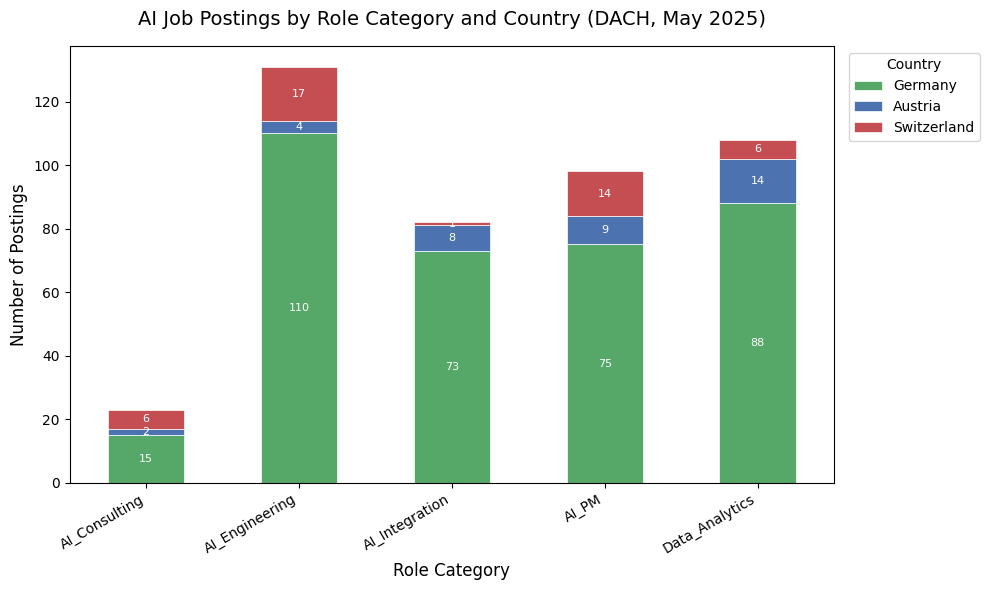

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

cross = pd.crosstab(df["role_category"], df["country"])[["Germany", "Austria", "Switzerland"]]
cross.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#55A868", "#4C72B0", "#C44E52"],
    edgecolor="white",
    linewidth=0.5
)

ax.set_title("AI Job Postings by Role Category and Country (DACH, May 2025)", fontsize=14, pad=15)
ax.set_xlabel("Role Category", fontsize=12)
ax.set_ylabel("Number of Postings", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left")

for bar_container in ax.containers:
    ax.bar_label(bar_container, label_type="center", fontsize=8, color="white", fmt="%d")

plt.tight_layout()
plt.savefig("viz1_postings_by_role_country.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualization 2: Salary Midpoint Distribution by Role Category (box plot)

/var/folders/m4/v_y_svfs5nl1m655kfv_nkth0000gn/T/ipykernel_1796/783327724.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/m4/v_y_svfs5nl1m655kfv_nkth0000gn/T/ipykernel_1796/783327724.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


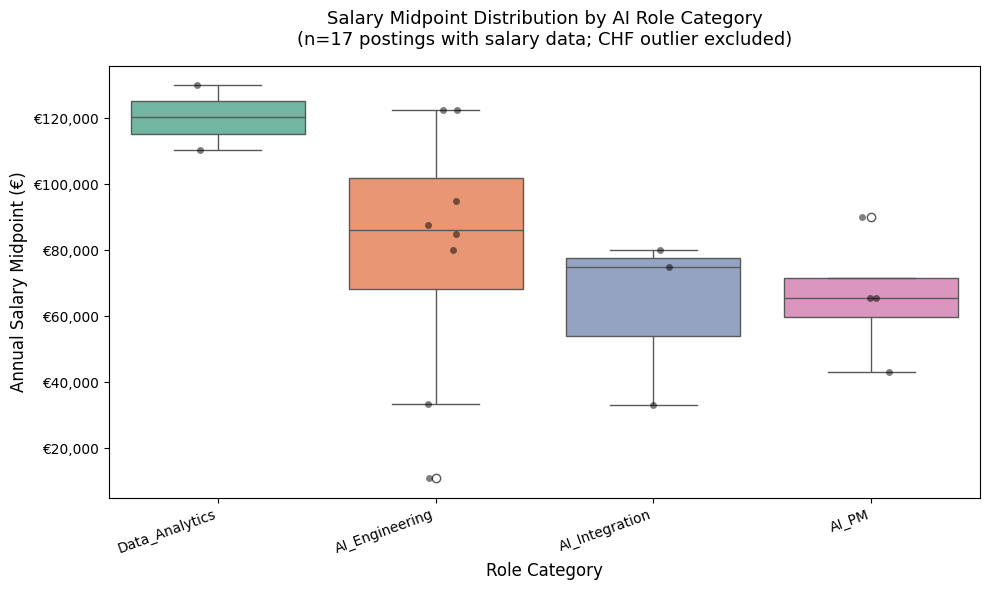

In [55]:
sal_df = df[df["salary_midpoint"].notna()].copy()

# Exclude the Switzerland 416k outlier for a readable plot
# (likely CHF not EUR — flagged in analysis)
sal_df_plot = sal_df[sal_df["salary_midpoint"] < 200000]

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=sal_df_plot,
    x="role_category",
    y="salary_midpoint",
    palette="Set2",
    order=sal_df_plot.groupby("role_category")["salary_midpoint"].median().sort_values(ascending=False).index,
    ax=ax
)

sns.stripplot(
    data=sal_df_plot,
    x="role_category",
    y="salary_midpoint",
    color="black",
    alpha=0.5,
    size=5,
    order=sal_df_plot.groupby("role_category")["salary_midpoint"].median().sort_values(ascending=False).index,
    ax=ax
)

ax.set_title("Salary Midpoint Distribution by AI Role Category\n(n=17 postings with salary data; CHF outlier excluded)", fontsize=13, pad=15)
ax.set_xlabel("Role Category", fontsize=12)
ax.set_ylabel("Annual Salary Midpoint (€)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

plt.tight_layout()
plt.savefig("viz2_salary_by_role.png", dpi=150, bbox_inches="tight")
plt.show()


### Visualization 3: Top 15 Hiring Locations across DACH

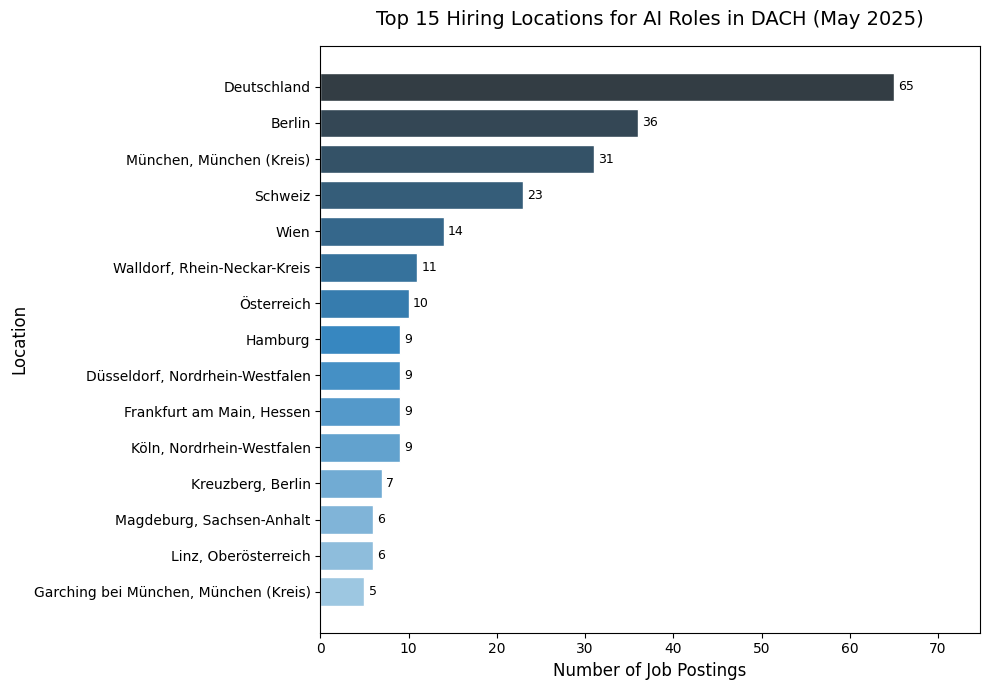

In [57]:
# Clean up location names: strip country suffixes for readability
location_counts = (
    df["location"]
    .str.replace(r",\s*(Deutschland|Österreich|Schweiz)$", "", regex=True)
    .str.strip()
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    location_counts.index[::-1],
    location_counts.values[::-1],
    color=sns.color_palette("Blues_d", len(location_counts)),
    edgecolor="white"
)

ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Top 15 Hiring Locations for AI Roles in DACH (May 2025)", fontsize=14, pad=15)
ax.set_xlabel("Number of Job Postings", fontsize=12)
ax.set_ylabel("Location", fontsize=12)
ax.set_xlim(0, location_counts.max() * 1.15)

plt.tight_layout()
plt.savefig("viz3_top_locations.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary and Interpretation

### What I Learned from the Dataset

This analysis explored 442 live AI job postings scraped from the Adzuna API across Germany, Austria and Switzerland in May 2025. The data confirms that Germany dominates the DACH AI job market in raw volume, accounting for 361 of 442 postings (82%), while Austria and Switzerland together contribute the remaining 18%. AI Engineering and Data Analytics are the most advertised role categories, followed closely by AI Product and Project Management. Berlin, Munich and Frankfurt emerge as the primary hiring hubs in Germany, with Vienna and Zurich leading in their respective countries.

### Interesting Patterns and Insights

The most structurally revealing finding is the near-total absence of salary data: only 18 of 442 postings (4%) disclose any compensation figures. This is not random noise — it reflects a deliberate and widespread practice among European employers of omitting salary ranges from job advertisements. Among the postings that do disclose salary, AI Engineering roles cluster between €65,000 and €105,000, while Data Analytics roles show higher midpoints despite smaller sample sizes. The correlation matrix reveals a moderate positive relationship (r = 0.52) between country and salary midpoint, driven almost entirely by Switzerland's single disclosed salary of 416,000 — certainly denominated in CHF rather than EUR.

AI Consulting is notably underrepresented with only 23 postings despite being a high-demand role type in practice. This likely reflects the fact that senior consulting positions in the DACH region are predominantly filled through executive search firms, professional networks and direct company career pages rather than aggregator platforms like Adzuna.

### Limitations and Assumptions

Several limitations apply to this dataset and should be considered when interpreting results. First, the data was collected through keyword-based API queries, meaning the role categories reflect search terms rather than verified job classifications — a single posting may appear under multiple categories before deduplication. Second, salary figures were accepted at face value without currency normalisation; the Swiss posting of 416,000 was excluded from visualisations but included in raw statistics, which affects mean calculations. Third, the dataset represents a single point-in-time snapshot from May 2025 and cannot capture seasonal hiring fluctuations or longer-term market trends. Finally, Adzuna's coverage of the DACH market is uneven — it indexes a subset of available postings and likely over-represents larger companies and technical roles while under-representing SME hiring and business-facing AI positions.

### Surprising or Unclear Findings

The high volume of AI Integration postings (82 total) was unexpected and suggests stronger-than-anticipated demand for professionals who implement and deploy AI systems rather than build them — a role profile closely aligned with business informatics and project management backgrounds. It is unclear from the data alone whether this reflects genuine market demand or an artefact of the search terms used. Additionally, the near-equal split between full-time and unlabelled contract arrangements (179 full-time vs. 251 with no contract data) makes it impossible to draw reliable conclusions about remote work prevalence or employment flexibility from this dataset alone.